In [1]:
# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
# NOTE: PYTHONPATH must be set correctly to include the project src directory
# in order to find the nndl module file
from nndl import vectorize_samples, plot_history

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

I0000 00:00:1779042356.482686   32161 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779042357.058386   32161 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.4 Improving generalization

Once your model has shown itself to have some generalization power and to be able
to overfit, it’s time to switch your focus to maximizing generalization

### 5.4.1 Dataset curation

### 5.4.2 Feature engineering

### 5.4.3 Using early stopping

### 5.4.4 Regularizing your model

Regularization techniques are a set of best practices that actively impede the model’s ability
to fit perfectly to the training data, with the goal of making the model perform better
during validation.

#### Reducing the network's size

The simplest way to mitigate overfitting when working with neural networks is to reduce the size of the model.
That is to say, reduce the number of learnable parameters available to the model, which is determined by
the number of layers and the number of hidden units in each layer. If the model has limited memorization resources, it won’t be able to
simply memorize its training data; thus, in order to minimize its loss, it will have to
resort to learning compressed representations that have predictive power regarding
the targets.

At the same time, keep in mind that you should use models that have enough parameters that they
don’t underfit: your model shouldn’t be starved for memorization resources. There is
a compromise to be found between too much capacity and not enough capacity.

There is no real formula to determine the right size and capacity for your model.  You have to 
evaluate a sample of different architectures (on your validation set) in order to find a good range of 
capacity for your problem.  The general workflow is to start with relatively few layers and parameters,
and increase the size of the layers or add new layers until you see diminishing returns with regard
to validation loss.

Lets try this approach on the movie-review binary classification model.  Here is the original model
from the previous unit.

In [3]:
from tensorflow.keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

train_data = vectorize_samples(train_data)

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_original = model.fit(train_data, train_labels,
                             epochs=20, batch_size=512, validation_split=0.4)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 57s 3us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7706 - loss: 0.5306 - val_accuracy: 0.8728 - val_loss: 0.3884
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8935 - loss: 0.3226 - val_accuracy: 0.8828 - val_loss: 0.3119
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9213 - loss: 0.2368 - val_accuracy: 0.8890 - val_loss: 0.2862
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9363 - loss: 0.1937 - val_accuracy: 0.8886 - val_loss: 0.2798
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9502 - loss: 0.1576 - val_accuracy: 0.8843 - val_loss: 0.2891
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1331 - val_accuracy: 0.8744 - val_loss: 0.3222
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9627 - loss: 0.1178 - val_accuracy: 0.8835 - val_loss: 0.3012
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9

Now lets train a smaller model so that we can compare the effect on the validation loss of the original
larger model with a smaller model.

In [4]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_smaller_model = model.fit(train_data, train_labels,
                                  epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6579 - loss: 0.6204 - val_accuracy: 0.7171 - val_loss: 0.5667
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7894 - loss: 0.5327 - val_accuracy: 0.8249 - val_loss: 0.5220
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8465 - loss: 0.4857 - val_accuracy: 0.8055 - val_loss: 0.4987
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8817 - loss: 0.4528 - val_accuracy: 0.8344 - val_loss: 0.4788
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9059 - loss: 0.4260 - val_accuracy: 0.8616 - val_loss: 0.4628
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9225 - loss: 0.4047 - val_accuracy: 0.8785 - val_loss: 0.4514
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9390 - loss: 0.3845 - val_accuracy: 0.8597 - val_loss: 0.4539
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9480 - loss: 0.3675 - val_accuracy: 0.8404 - val_loss

Lets compare the validation loss of the original larger model to this smaller model.

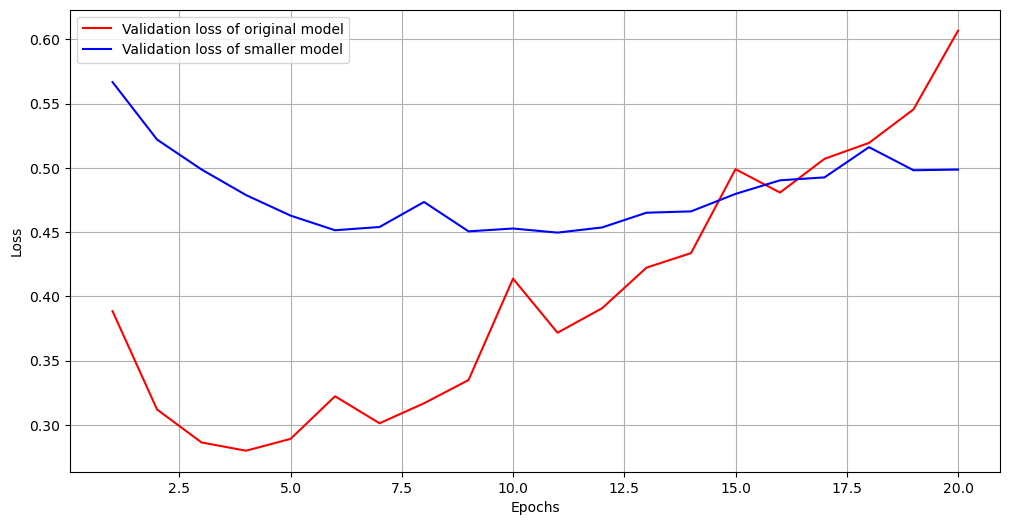

In [5]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of original model')
plt.plot(epochs, history_smaller_model.history['val_loss'], 'b-', label='Validation loss of smaller model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

As you should normally see, the smaller model is overfitting, but later than the original model, and its performance degrades
more slowly once it starts overfitting.

Now lets add in a model with even more capacity than the original model, far more than the problem warrants.  
While it is standard to work with models that are significantly over parameterized for what they're trying to learn,
there can definitely be such a thing as too much memorization capacity. You'll know your model is too large
if it starts overfitting right away and if its validation loss curve looks choppy with high variance.

Here is a model with larger capacity than the original.

In [6]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_larger_model = model.fit(train_data, train_labels,
                                 epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6997 - loss: 0.5863 - val_accuracy: 0.8555 - val_loss: 0.3830
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8737 - loss: 0.3155 - val_accuracy: 0.8812 - val_loss: 0.2908
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8985 - loss: 0.2501 - val_accuracy: 0.8675 - val_loss: 0.3105
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9306 - loss: 0.1774 - val_accuracy: 0.8904 - val_loss: 0.2822
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9443 - loss: 0.1501 - val_accuracy: 0.8846 - val_loss: 0.3162
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9543 - loss: 0.1190 - val_accuracy: 0.8838 - val_loss: 0.3061
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9734 - loss: 0.0848 - val_accuracy: 0.8838 - val_loss: 0.3489
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9764 - loss: 0.0764 - val_accuracy: 0.8837 - v

Here are all three models validation loss for comparison.

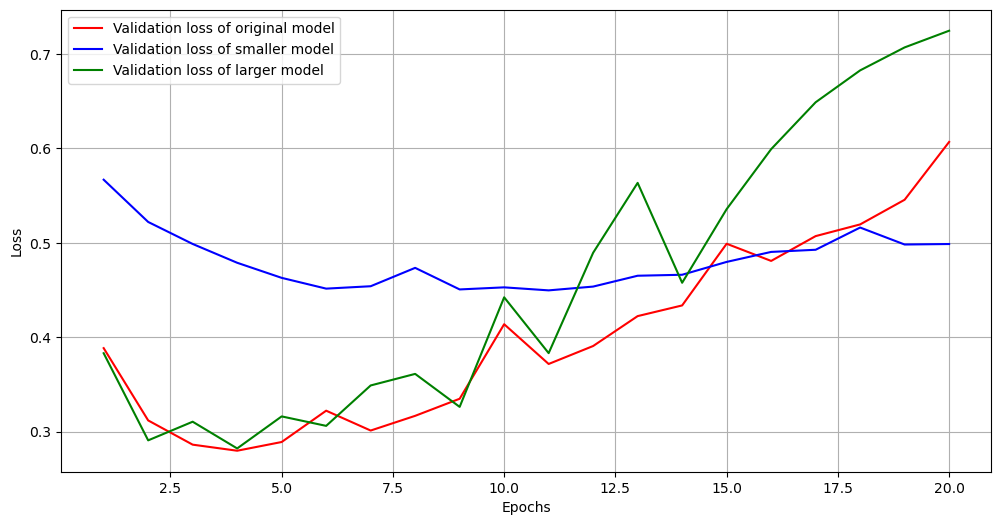

In [7]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of original model')
plt.plot(epochs, history_smaller_model.history['val_loss'], 'b-', label='Validation loss of smaller model')
plt.plot(epochs, history_larger_model.history['val_loss'], 'g-', label='Validation loss of larger model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

The larger model will usually when you rerun these cells start overfitting and increasing loss before the original and small
models.  Also its validation loss will often look noisier.  If you look at the training loss from this large model, 
it essentially gets driven to 0 after 10 epochs or so.  The more capacity the model has, the more quickly it
can model the training data (resulting in low training loss), but the more susceptible it is to overfitting.

#### Adding weight regularization

Given some training data and a given network architecture with a given set of trainable parameters, multiple settings of
the parameters can be obtained that will explain / model the data.  Simpler models are less likely to overfit
than complex ones.  So regularization are ways to constrain training to prefer simpler models to be learned for
the training data.

A **simple model** in this context is a model where the distribution of parameter values
has less entropy.  Thus, a common way to mitigate overfitting is to put constraints on the complexity
of a model by forcing its weights to take only small values, which makes the distribution of weight
values more **regular**.

This is called **weight regularization** and it is done by adding to the loss function of the model a cost associated with
having large weights.  There are two common loss penalties used for regularization:

- L1 regularization—The cost added is proportional to the absolute value of the
  weight coefficients (the L1 norm of the weights).
- L2 regularization—The cost added is proportional to the square of the value of the
  weight coefficients (the L2 norm of the weights).

In `keras` weight regularization is added by passing **weight regularizer instances**
to layers as keyword arguments.  Let's show the effect of adding L2 weight regularization
to our original movie-review binary classification model.

In [8]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_l2_reg = model.fit(train_data, train_labels,
                           epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7737 - loss: 0.6111 - val_accuracy: 0.8633 - val_loss: 0.4749
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8929 - loss: 0.4010 - val_accuracy: 0.8795 - val_loss: 0.3898
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9110 - loss: 0.3326 - val_accuracy: 0.8809 - val_loss: 0.3706
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9245 - loss: 0.2940 - val_accuracy: 0.8894 - val_loss: 0.3537
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9336 - loss: 0.2712 - val_accuracy: 0.8853 - val_loss: 0.3621
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9387 - loss: 0.2567 - val_accuracy: 0.8711 - val_loss: 0.3984
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9431 - loss: 0.2476 - val_accuracy: 0.8672 - val_loss: 0.4074
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9491 - loss: 0.2347 - val_accuracy: 0.8670 - val_loss

In this example, as you can see, the regularization is added to both layers using `regularizers.l2(0.002)`.
The value `0.002` is the alpha parameter that controls the effect that the regularization penalty has
with respect to the loss function.  So the layer will effectively add `0.002 * weight_coefficient_value**2` to every
weight.  The larger the weight, the larger this penalty is, thus increasing the loss.

**Note**: When using regularization, the penalty is only added at training time.  So the training loss will be 
(possibly much) higher than what the validation loss appears to be when you are using regularization.

Again lets look at the effect of regularization on this model.  Here we show this new model using L2
regularization against the original model, and the effect the regularization has on the validation loss.

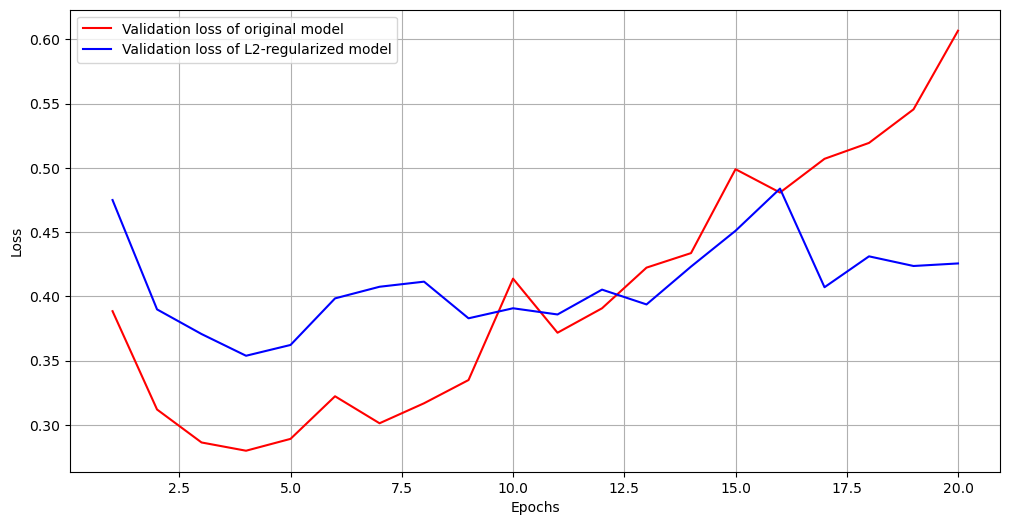

In [9]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of original model')
plt.plot(epochs, history_l2_reg.history['val_loss'], 'b-', label='Validation loss of L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

As you should usually see, the model with L2 regularization has become more resistant to overfitting.  Overfitting
occurs later in the training epochs and proceeds more slowly, even though both models have the same
capacity (same number of trainable parameters).

As an alternative to L2 regularization, you can use L1 regularization (which computes the
error using the absolute value of the weights), or you can combine and use both L1 and
L2 regularization together.

```python
from tensorflow.keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# simultaneous L1 and L2 regularization
regularizers.l1_l2(l1=0.001, l2=0.001)
```

Note that weight regularization is more typically used for smaller deep learning models.  Large
deep learning models tend to be so over parameterized that imposing constraints on weight values
hasn't much impact on model capacity and generalization.  In these cases, a different 
regularization technique is preferred for neural network like models: dropout.

#### Adding dropout

**Dropout** is one of the most effective and most commonly used regularization techniques
for neural networks.  Dropout, applied to a layer, consists of randomly dropping out
(setting to zero) a number of output features of the layer during training.
The dropout rate is the fraction of the features that are zeroed out.

Just as ane example, if the dropout rate is 50%, and we have the output tensor
from a layer named `layer_output`, we could simulate random dropout doing
something like the following:

In [10]:
# to illustrate, an output layer has shape 5 samples by 10 features (5, 10)
layer_output = np.random.randn(5, 10)
print(layer_output)

[[ 0.1083 -0.4197  1.526  -0.8275  0.8936  0.4851 -0.9042  1.2349 -0.8017
   0.0415]
 [-0.3555 -0.2627  1.8273 -0.0058 -0.0842 -0.0458 -0.2284  0.611   0.7233
   1.0842]
 [-2.7078  0.8128  0.6692  0.0092  0.7146  0.9071 -0.4898  0.0084 -1.817
   0.5107]
 [-2.602   0.013  -1.3698  0.8483  0.0186  0.7538  1.508   0.3211  0.0173
   0.3411]
 [-0.2082  1.7076  0.4461 -1.3403  0.6893  0.6558  1.2544  0.4465  1.1586
  -1.1507]]


In [11]:
# generate a random matrix of random integers of the same shape, 50% 0 and 50% 1
dropout_mask = np.random.randint(0, high=2, size=layer_output.shape)
print(dropout_mask)

[[0 1 1 1 1 1 0 0 1 1]
 [1 1 0 0 0 1 0 1 0 1]
 [0 0 1 1 1 1 1 0 0 1]
 [0 1 0 1 1 1 1 0 1 1]
 [1 1 1 0 1 0 1 0 0 0]]


In [12]:
# multiplying by mask randomly drops out 50% of the output values
layer_output_dropped = layer_output * dropout_mask
print(layer_output_dropped)

[[ 0.     -0.4197  1.526  -0.8275  0.8936  0.4851 -0.      0.     -0.8017
   0.0415]
 [-0.3555 -0.2627  0.     -0.     -0.     -0.0458 -0.      0.611   0.
   1.0842]
 [-0.      0.      0.6692  0.0092  0.7146  0.9071 -0.4898  0.     -0.
   0.5107]
 [-0.      0.013  -0.      0.8483  0.0186  0.7538  1.508   0.      0.0173
   0.3411]
 [-0.2082  1.7076  0.4461 -0.      0.6893  0.      1.2544  0.      0.
  -0.    ]]


At test time, we scale down the output by the dropout rate.  So if we were
using a 50% dropout, when we do predictions for testing, all weights would
be scaled down by 50%.  This is because the size of the weights learned with
dropouts will be 50% larger than if no dropout were used.  So to
compensate once we finish training, we scale down by the same amount so
that we get a similar output level as we do when dropout is being applied.

In [13]:
# At test time, when making predictions, scale down output
layer_output = layer_output * 0.5
print(layer_output)

[[ 0.0542 -0.2099  0.763  -0.4137  0.4468  0.2426 -0.4521  0.6175 -0.4008
   0.0208]
 [-0.1778 -0.1313  0.9136 -0.0029 -0.0421 -0.0229 -0.1142  0.3055  0.3616
   0.5421]
 [-1.3539  0.4064  0.3346  0.0046  0.3573  0.4536 -0.2449  0.0042 -0.9085
   0.2553]
 [-1.301   0.0065 -0.6849  0.4242  0.0093  0.3769  0.754   0.1606  0.0086
   0.1706]
 [-0.1041  0.8538  0.223  -0.6702  0.3447  0.3279  0.6272  0.2233  0.5793
  -0.5753]]


Note that this process can be implemented by doing both operations at training
time, and leaving the output unchanged at test time, which is often the
way it's implemented in practice.

This technique may not make sense to you at first thought, how does
randomly zeroing out output results during training improve
generalization of the network while learning?  The core idea is that introducing
noise in the output values of a layer can break up happenstance patterns that aren’t significant.

In `keras` we can introduce dropout regularization to a model by inserting `Dropout` layers
in the network architecture. A `Dropout` layer is applied to the output of the
layer immediately preceding it.  Let's add `Dropout` layers in the IMDB model
to see how well they do at reducing overfitting.

In [14]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6413 - loss: 0.6296 - val_accuracy: 0.8485 - val_loss: 0.5114
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7600 - loss: 0.5138 - val_accuracy: 0.8730 - val_loss: 0.4100
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8177 - loss: 0.4336 - val_accuracy: 0.8799 - val_loss: 0.3498
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8564 - loss: 0.3661 - val_accuracy: 0.8842 - val_loss: 0.3029
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8771 - loss: 0.3180 - val_accuracy: 0.8900 - val_loss: 0.2815
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8976 - loss: 0.2806 - val_accuracy: 0.8843 - val_loss: 0.2807
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9099 - loss: 0.2519 - val_accuracy: 0.8899 - val_loss: 0.2800
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9229 - loss: 0.2225 - val_accuracy: 0.8887 - val_loss

And again lets compare the effect of dropout regularization on validation loss with what the original
model without dropout was doing.

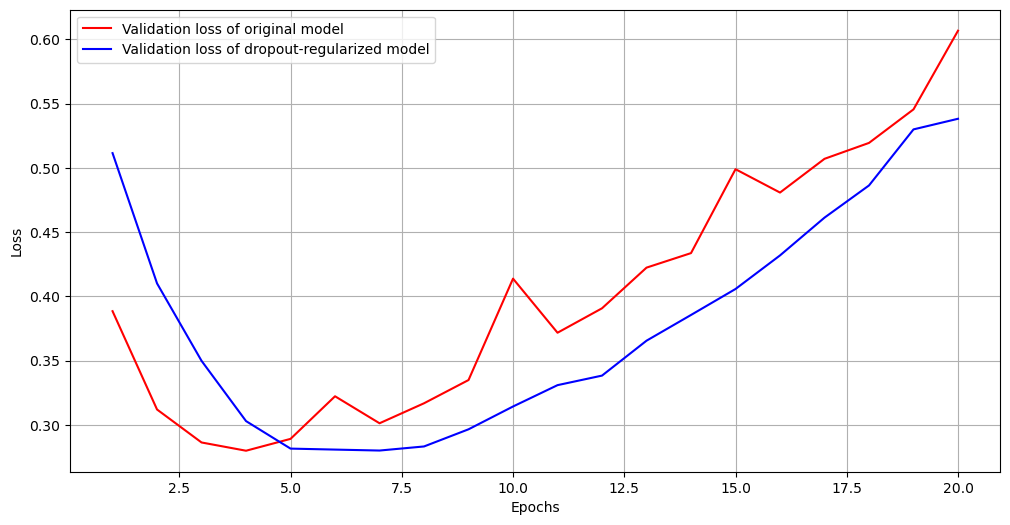

In [15]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of original model')
plt.plot(epochs, history_dropout.history['val_loss'], 'b-', label='Validation loss of dropout-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

Usually you will see a similar effect as with the L1/L2 regularization.  Overfitting will occur later and validation loss will
degrade slower than for the unregularized original model.

To recap, here is what you should remember about the most common ways to maximize generalization and
prevent overfitting in neural network models:

<font color='blue'>

- Get more training data, or better training data.
- Develop better features.
- Reduce the capacity of the model.
- Add weight regularization (for smaller models).
- Add dropout.

# Chapter Summary

Things to remember about fundamental Machine Learning concepts in the context of training neural networks and
deep network models:

<font color='blue'>

- The purpose of a machine learning model is to generalize: to perform accurately
  on never-before-seen inputs.
- A deep neural network achieves generalization by learning a parametric model
  that can successfully interpolate between training samples (learning a latent manifold).
- The fundamental problem in machine learning is the tension between optimization
  and generalization.  To again generalization you must first achieve a good
  fit to the model, but improving a models fit (training loss) will inevitably start
  hurting generalization.  **Every single deep learning best practice deals with managing this tension**.
- The ability of deep learning models to generalize comes from the fact that they
  manage to learn to approximate the latent manifold of their data, and can thus
  make sense of new inputs via interpolation.
- It’s essential to be able to accurately evaluate the generalization power of your
  model while you’re developing it.
  - Simple holdout validation
  - K-fold cross-validation and iterated K-fold cross-validation (especially when size of data is small)
  - Test set needs to be kept for final model evaluation, not used when validating models.
- When you start working on a model, your goal is first to achieve a model that
  has some generalization power and that can overfit.
- As your model starts overfitting, your goal switches to improving generalization
  through model regularization. You can reduce your model’s capacity, add dropout
  or weight regularization, and use early stopping. And naturally, a larger or better
  dataset is always the number one way to help a model generalize.